# Beyond the Canopy: Predicting Deforestation Risk Along Brazil's BR-163 Highway Using Satellite Imagery and Socioeconomic Drivers

**67-364 Practical Data Science — Spring 2026**  
**Student:** Iroda Ibrohimova (iibrohim)  
**Data Analysis Report — Project Deliverable 2**

### Dataset Load

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

PALETTE = {'intact': '#2d8a4e', 'deforested': '#c0392b'}

# Load dataset 
df = pd.read_csv('br163_grid_FINAL.csv')

# Drop helper columns
df = df.drop(columns=['cell_row', 'cell_col', 'dist_bin', 'loss_pct'], errors='ignore')

# Map land cover codes to labels
LC_MAP = {
    3: 'forest', 4: 'savanna_forest', 6: 'flooded_forest',
    9: 'savanna', 11: 'wetland', 12: 'grassland',
    15: 'pasture', 20: 'agriculture', 21: 'mosaic',
    24: 'urban', 25: 'non_vegetated', 29: 'rocky',
    30: 'mining', 31: 'aquaculture', 33: 'water',
    39: 'soybean', 41: 'other_crop', 62: 'cotton'
}
df['land_cover'] = df['land_cover'].map(LC_MAP).fillna('other')
df['land_cover'] = df['land_cover'].astype('category')

# Fix dtypes
for col in ['deforested', 'protected_area', 'agri_conversion']:
    df[col] = df[col].astype(int)

# Log transforms
df['log_dist_highway'] = np.log1p(df['dist_highway_km'])
df['log_dist_road']    = np.log1p(df['dist_road_km'])
df['log_fire_cell']    = np.log1p(df['fire_count_cell'])
df['log_fire_buffer']  = np.log1p(df['fire_count_buffer'])

print(f"Dataset loaded: {df.shape}")
print(f"Target: {df['deforested'].value_counts().to_dict()}")

Dataset loaded: (342819, 21)
Target: {0: 279572, 1: 63247}


---
## Section 1: Data Preparation for Training

### 1a. Feature Engineering

In [5]:

# One-hot encode land_cover
df_model = pd.get_dummies(df, columns=['land_cover'], drop_first=False, dtype=int)

# Dropping redundant features identified in EDA:

drop_cols = ['evi', 'fire_count_buffer', 'dist_highway_km', 'dist_road_km']
df_model = df_model.drop(columns=drop_cols, errors='ignore')

# Confirm final feature set
feature_cols = [c for c in df_model.columns if c != 'deforested']
print(f"Shape: {df_model.shape}")
print(f"\nFinal features ({len(feature_cols)}):")
for c in feature_cols:
    print(f"  {c}")

Shape: (342819, 30)

Final features (29):
  lat
  lon
  treecover_2000_pct
  fire_count_cell
  protected_area
  dist_protected_km
  dist_settlement_km
  agri_conversion
  evi_change
  ndvi_mean
  ndvi_change
  log_dist_highway
  log_dist_road
  log_fire_cell
  log_fire_buffer
  land_cover_flooded_forest
  land_cover_forest
  land_cover_grassland
  land_cover_mining
  land_cover_non_vegetated
  land_cover_other_crop
  land_cover_pasture
  land_cover_rocky
  land_cover_savanna
  land_cover_savanna_forest
  land_cover_soybean
  land_cover_urban
  land_cover_water
  land_cover_wetland


### 1a. Feature Engineering

**One-hot encoding: `land_cover`**  
`The dataset contains one categorical variable: land_cover, which records the land use type of each grid cell (e.g., forest, pasture, mining, agriculture). This variable is nominal, meaning there is no meaningful numeric order between its categories. Encoding it with label encoding (assigning integers like forest=1, pasture=2, mining=3) would falsely imply that pasture is "twice" forest, which would mislead any linear model. One-hot encoding was used instead, converting each land cover category into its own binary 0/1 column. This allows every model to treat each land cover type as a completely independent signal, with no assumed ordering between them.

**Redundant features dropped based on EDA correlation analysis:**

- `evi`: r = 0.995 with `ndvi_mean`: these two are nearly perfectly correlated and carry identical information. Keeping both adds noise without adding signal.
- `fire_count_buffer`: r = 0.714 with `fire_count_cell`, and `log_fire_buffer` already captures the same neighbourhood fire signal in a better-distributed form.
- `dist_highway_km`: replaced by `log_dist_highway`: the raw distance is heavily right-skewed. The log transform compresses the long tail and produces a more informative feature for both linear and tree-based models.
- `dist_road_km`: same reasoning as above, replaced by `log_dist_road`.

**No new features**
The four log transforms above (log_dist_highway, log_dist_road, log_fire_cell, log_fire_buffer) were created in the Data Analysis Report and carried forward here unchanged.
**No SMOTE or resampling was applied (Class Imbalance/)**: The training set contains 223,657 intact cells and 50,598 deforested cells, a ratio of approximately 4.42 to 1. Rather than resampling the data with SMOTE or oversampling, all classifiers are trained with class_weight='balanced', which automatically assigns a higher loss penalty to minority class misclassifications during training. Concretely, sklearn computes a weight of 0.61 for intact cells and 2.71 for deforested cells: every time the model misclassifies a deforested cell, the penalty is 4.4 times heavier than misclassifying an intact cell.
SMOTE was not used because it is designed for severe class imbalance (ratios of 95/5 or worse) where there are too few real minority examples for the model to learn from. Here, there are 50,598 real deforested cells in the training set, far more than enough for any model to learn the deforestation pattern from real data. Generating synthetic examples via interpolation would introduce noise without adding genuine signal. The final XGBoost model achieved a recall of 0.947 on the deforested class, confirming that class_weight='balanced' was sufficient without any resampling.

### 1b. Data Splitting Strategy

An 80/20 train/test split was used. The dataset contains 342,819 rows, which produces a training set of approximately 274,255 rows and a test set of approximately 68,564 rows. This is large enough that an 80/20 ratio gives the model ample data to learn from while keeping a meaningful held-out evaluation set.
Stratified splitting was applied. This ensures that both the training and test sets preserve the same 81.6% / 18.4% class ratio as the full dataset. Without stratification, random chance could produce a test set with a noticeably different proportion of deforested cells, making evaluation results unreliable.
random_state=42 was set throughout. This pins the split to a specific random permutation, so anyone running this notebook on the same data will get identical training and test sets.
The test set was set aside immediately after splitting and was not used at any point during model training, cross-validation, or hyperparameter tuning. All model selection decisions were made using cross-validation scores computed on the training set only. The test set was used exclusively for the final evaluation reported in Sections 3 and 4.

In [8]:
X = df_model.drop(columns=['deforested', 'lat', 'lon'])
y = df_model['deforested']

# stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nClass balance in train — intact: {(y_train==0).sum():,} | deforested: {(y_train==1).sum():,}")
print(f"Class balance in test  — intact: {(y_test==0).sum():,} | deforested: {(y_test==1).sum():,}")
print(f"\nTrain deforested %: {y_train.mean()*100:.1f}%")
print(f"Test  deforested %: {y_test.mean()*100:.1f}%")
print(f"\nFeatures used: {X_train.shape[1]}")

Training set:   274,255 rows (80.0%)
Test set:       68,564 rows (20.0%)

Class balance in train — intact: 223,657 | deforested: 50,598
Class balance in test  — intact: 55,915 | deforested: 12,649

Train deforested %: 18.4%
Test  deforested %: 18.4%

Features used: 27


### 1c. Feature Scaling
**StandardScaler** (zero mean, unit variance) was applied to all continuous features, but only for Logistic Regression. It was not applied to Random Forest or XGBoost.
**Logistic Regression** uses gradient-based optimisation to learn feature weights. When features are on very different scales (for example, dist_settlement_km ranges from 0 to over 100 km while ndvi_mean ranges from roughly -1 to 1), gradient steps are dominated by the large-scale features and the small-scale ones are effectively ignored. Standardising all features to the same scale ensures every feature has an equal opportunity to influence the model during training.
Tree-based models such as **Random Forest and XGBoost** are completely scale-invariant. They split on feature thresholds, not magnitudes, so whether a feature is measured in kilometres or normalised units makes no difference to where the split is placed. Scaling these models would waste computation with no effect on results.
Data leakage prevention: The scaler was fit exclusively on X_train and then applied to X_test using transform only, never fit_transform. Fitting the scaler on the full dataset before splitting would leak test set distribution statistics (mean and standard deviation) into the training process, artificially inflating performance estimates. This is a data leakage error and was avoided.

**Critical:** The scaler is fit **only on `X_train`**, then applied to `X_test`. Fitting on the full dataset before splitting would leak test set distribution into training.

>**A note on false negatives:** Throughout this project, minimising false negatives is treated as the primary operational concern. A false negative means a grid cell that is actively being deforested is predicted as intact. In practice, this means the cell receives no monitoring attention and no enforcement response while clearing continues. For BR-163 conservation work, this is a far more costly error than a false alarm. This priority directly shapes the choice of evaluation metrics and the final model selection in the sections that follow.

In [10]:
scaler = StandardScaler()

# Fit on training data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("Scaler fit on training data only.")
print(f"\nSample means after scaling (should be ~0):")
print(X_train_scaled[['ndvi_mean', 'log_fire_cell', 'log_dist_road', 'dist_settlement_km']].mean().round(4))
print(f"\nSample stds after scaling (should be ~1):")
print(X_train_scaled[['ndvi_mean', 'log_fire_cell', 'log_dist_road', 'dist_settlement_km']].std().round(4))

Scaler fit on training data only.

Sample means after scaling (should be ~0):
ndvi_mean             0.0
log_fire_cell         0.0
log_dist_road        -0.0
dist_settlement_km   -0.0
dtype: float64

Sample stds after scaling (should be ~1):
ndvi_mean             1.0
log_fire_cell         1.0
log_dist_road         1.0
dist_settlement_km    1.0
dtype: float64


---
## Section 2: Baseline Models

Before building and tuning more complex models, it is important to establish a performance floor. A baseline answers a fundamental question: **is the model actually learning anything useful, or could a much simpler rule achieve similar results?** Every metric reported in later sections should be interpreted relative to what a naive predictor can already achieve.Four models are evaluated here using default hyperparameters with no tuning at all. This serves two purposes. First, it gives a reference floor to measure how much improvement comes from tuning in Section 3. Second, it lets us compare all model families on equal footing before any optimisation is applied.All real models use class_weight='balanced' to account for the 4.42:1 class imbalance. A dummy majority-class classifier that always predicts "Intact" is also included to demonstrate concretely why accuracy alone is a misleading metric on this dataset.

### Evaluation Metrics — Choice and Justification
Choosing the right metrics is just as important as choosing the right model. For an imbalanced conservation problem like this one, the standard metric of accuracy is actively misleading. The metrics used throughout this report are selected because they each reveal something different and meaningful about model behaviour.

**Primary metric: AUC-ROC**  
AUC-ROC (Area Under the Receiver Operating Characteristic Curve) measures **how well the model separates deforested cells from intact ones across every possible classification threshold** simultaneously. A score of 0.5 means the model is no better than random guessing. A score of 1.0 means perfect separation. AUC-ROC is chosen as the primary metric because it is completely **unaffected by class imbalance**. Whether the dataset is 80/20 or 99/1, AUC-ROC evaluates the model's fundamental ability to rank deforested cells above intact ones, independent of any threshold decision. This makes it the most honest single-number summary of model quality here.

**Secondary metric: Recall (on the deforested class)**  
Recall measures what fraction of actually deforested cells the model correctly identifies:

$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$

A **False Negative** in this problem means a grid cell that is actively being cleared is predicted as intact. In operational terms, this cell receives no monitoring attention and no enforcement response while deforestation continues. This is the most costly possible error. Maximising recall directly minimises the number of real clearing events the model lets slip through undetected, which is why it is treated as the second most important metric throughout this report.

**Third metric: F1-Score (on the deforested class)**  
F1 is the harmonic mean of Precision and Recall. It rewards models that are both good at catching deforested cells (high recall) and not excessively over-flagging intact cells (high precision). It is reported alongside recall to give a complete picture of minority class performance. In cases where two models have similar recall, F1 distinguishes the one that does so more efficiently.

**Why NOT accuracy?**  
A classifier that predicts every single cell as "Intact" scores 81.6% accuracy on this dataset while catching zero deforested cells. It is technically the most accurate naive predictor, yet it is completely useless for conservation purposes. Accuracy is dominated by the majority class and gives no information about how the model handles the class that actually matters. It is reported for completeness only and plays no role in any model selection decision in this report.

**Summary:**

| Metric | Role | Why |
|---|---|---|
| AUC-ROC | Primary | Threshold-independent, imbalance-robust |
| Recall | Secondary | Minimises missed deforestation (false negatives) |
| F1-Score | Supporting | Balances precision and recall |
| Accuracy | Reported only | Misleading on imbalanced data — not used for selection |

In [13]:
#Baseline Models 
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Define baselines
baselines = {
    'Majority Class':     DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                         random_state=42, eval_metric='logloss', verbosity=0),
}

results_baseline = {}

for name, model in baselines.items():
    # LR uses scaled data, others use raw
    Xtr = X_train_scaled if name == 'Logistic Regression' else X_train
    Xte = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    results_baseline[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'F1 (deforested)': round(f1_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 4),
    }
    print(f" {name} done")

# Summary table
results_df = pd.DataFrame(results_baseline).T
print("BASELINE RESULTS (default settings, no tuning)")
print(results_df.to_string())

 Majority Class done
 Logistic Regression done
 Decision Tree done
 Random Forest done
 XGBoost done
BASELINE RESULTS (default settings, no tuning)
                     Accuracy  F1 (deforested)  AUC-ROC
Majority Class         0.8155           0.0000   0.5000
Logistic Regression    0.9367           0.8435   0.9812
Decision Tree          0.9359           0.8250   0.8908
Random Forest          0.9548           0.8742   0.9876
XGBoost                0.9452           0.8648   0.9889


### Baseline Results — Interpretation

**Majority Class classifier** scores 81.6% accuracy while catching zero deforested cells (F1=0, AUC=0.5). This confirms that accuracy is a useless metric for this problem and justifies our choice of F1 and AUC-ROC throughout.

**Logistic Regression** performs surprisingly well (AUC=0.981, F1=0.844) given it is a simple linear model. This makes sense: the EDA showed strong linear signals in log fire count, NDVI change, and log distance to road. A linear boundary captures most of the discrimination.

**Decision Tree** has the lowest AUC (0.891) among real models despite decent accuracy. Decision trees with default settings tend to overfit (unlimited depth), which hurts generalisation. Its AUC drop relative to the other models suggests it is memorising training noise.

**Random Forest** leads on F1 (0.874) and is near the top on AUC (0.988). Ensemble averaging over 100 trees smooths out the overfitting problem of individual decision trees.

**XGBoost** leads on AUC (0.989) at default settings, confirming that gradient boosting is the strongest baseline. The gap over Random Forest is small but consistent.

**Key takeaway:** All four real models dramatically outperform the majority-class baseline. Random Forest and XGBoost are the strongest candidates. Section 3 will tune these further to see how much improvement is possible over these default results.

In [15]:
# Checking for overfitting
from sklearn.metrics import roc_auc_score

for name, model in baselines.items():
    Xtr = X_train_scaled if name == 'Logistic Regression' else X_train
    Xte = X_test_scaled  if name == 'Logistic Regression' else X_test
    
    if hasattr(model, 'predict_proba'):
        train_auc = roc_auc_score(y_train, model.predict_proba(Xtr)[:,1])
        test_auc  = roc_auc_score(y_test,  model.predict_proba(Xte)[:,1])
        gap = train_auc - test_auc
        print(f"{name:22s}  train AUC={train_auc:.4f}  test AUC={test_auc:.4f}  gap={gap:.4f}")

Majority Class          train AUC=0.5000  test AUC=0.5000  gap=0.0000
Logistic Regression     train AUC=0.9813  test AUC=0.9812  gap=0.0001
Decision Tree           train AUC=1.0000  test AUC=0.8908  gap=0.1092
Random Forest           train AUC=1.0000  test AUC=0.9876  gap=0.0124
XGBoost                 train AUC=0.9936  test AUC=0.9889  gap=0.0047


### Train vs Test AUC — Overfitting Check

**Decision Tree** is the clearest case of overfitting — train AUC = 1.0 (memorised every training cell perfectly) but test AUC drops to 0.891, a gap of 0.109. This is why default Decision Trees are not reliable: unlimited depth means the model learns noise instead of signal.

**Random Forest** also hits train AUC = 1.0 but test AUC stays at 0.988, gap of only 0.012. The ensemble averaging over 100 trees regularises the overfitting that kills individual trees. This is Random Forest's core strength.

**XGBoost** is the most well-behaved,  train AUC 0.994 vs test AUC 0.989, gap of only 0.005. It never fully memorised the training data, which means it generalised best. This is because XGBoost builds trees sequentially and each tree corrects only the residual errors of the previous one, making it naturally more conservative.

**Logistic Regression** has essentially zero gap (0.0001), the model is too simple to overfit. What it learns on training data transfers almost perfectly to test data.

**Key takeaway for Section 3:** Decision Tree needs pruning (max_depth limit) to be useful. Random Forest and XGBoost are strong candidates for tuning — their small gaps mean tuning will improve performance without causing overfitting.

---
## Section 3: Model Training, Evaluation and Justification
Three model types are trained and evaluated in this section: Logistic Regression, Random Forest, and XGBoost. These three were chosen because they represent fundamentally different learning approaches, a linear model, a parallel ensemble of trees, and a sequential boosting ensemble, which allows for a meaningful comparison of how different model families handle the same problem. The goal is not to try everything but to justify each choice and interpret every result in the context of the BR-163 conservation problem.
For every model, the same evaluation procedure applies: 5-fold stratified cross-validation on the training set for model selection and hyperparameter tuning, followed by a single final evaluation on the held-out test set. The test set was never used during training or tuning at any stage. The same evaluation metrics are used throughout: AUC-ROC, Recall, and F1-Score on the deforested class.

### 3.1 Logistic Regression

**a) Model Justification:**  
Logistic Regression works by modelling the log-odds of deforestation as a weighted sum of input features, then passing that through a sigmoid function to produce a probability between 0 and 1. The model assumes that a linear boundary can separate deforested from intact cells in feature space. The EDA supports this assumption: log fire count, NDVI change, and log distance to road all show strong, roughly monotonic relationships with deforestation probability. A linear boundary can capture most of that signal without needing to model complex interactions. The model is also highly interpretable: each feature coefficient has a direct, readable meaning in terms of its contribution to predicted deforestation risk.

**b) Training Approach**

Features were standardised using StandardScaler before training, as described in Section 1c. This is required for Logistic Regression because gradient-based optimisation is sensitive to feature scale: without scaling, features measured in large units dominate the gradient updates and features measured in small units are effectively ignored.

The only hyperparameter tuned was `C`, the inverse of regularisation strength. A small value of C applies strong regularisation by shrinking coefficients toward zero, producing a simpler and more constrained model. A large value of C reduces regularisation, allowing the model to fit more complex boundaries. A log-scale grid search was conducted over five values: 0.01, 0.1, 1, 10, and 100.

Tuning was performed using 5-fold stratified cross-validation on the training set only, with AUC-ROC as the scoring metric. Stratified folds were used to ensure each fold preserves the 4.42:1 class ratio, preventing any fold from being unrepresentative of the overall class distribution. The test set was not used at any point during this process and was only accessed for the final evaluation reported below.

Reproducibility was ensured by setting `random_state=42` on both the cross-validation splitter and the model itself.

**Assumptions met?**  
Features are scaled (done in 1c), which is required. No assumption of normality is needed for logistic regression, only linearity in the log-odds, which the EDA supports.

In [18]:
# Logistic Regression (trained)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                             confusion_matrix, classification_report)
from sklearn.metrics import recall_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

grid_lr = GridSearchCV(lr, param_grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_lr.fit(X_train_scaled, y_train)

print(f"Best C: {grid_lr.best_params_}")
print(f"Best CV AUC-ROC: {grid_lr.best_score_:.4f}")

# Evaluate on test set
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]


print("LOGISTIC REGRESSION — Test Set Results")

print(f"Accuracy:        {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 (deforested): {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:         {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"                  Pred Intact  Pred Deforested")
print(f"Actual Intact       {cm_lr[0,0]:>6,}          {cm_lr[0,1]:>6,}")
print(f"Actual Deforested   {cm_lr[1,0]:>6,}          {cm_lr[1,1]:>6,}")
print(f"\nFalse Negatives (missed deforestation): {cm_lr[1,0]:,}")
print(f"False Positives (false alarms):         {cm_lr[0,1]:,}")
print(f"Recall (deforested): {recall_score(y_test, y_pred_lr):.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import 

Best C: {'C': 0.01}
Best CV AUC-ROC: 0.9813
LOGISTIC REGRESSION — Test Set Results
Accuracy:        0.9369
F1 (deforested): 0.8438
AUC-ROC:         0.9812

Confusion Matrix:
                  Pred Intact  Pred Deforested
Actual Intact       52,550           3,365
Actual Deforested      963          11,686

False Negatives (missed deforestation): 963
False Positives (false alarms):         3,365
Recall (deforested): 0.9239



#### c) Evaluation Metrics and Results Interpretation

The model was evaluated on the held-out test set of 68,564 rows after tuning was complete.

**Best C = 0.01.** The model strongly prefers heavy regularisation. With over 274,000 training rows and only 27 features, the model is nowhere near the risk of overfitting. Strong regularisation stabilises the coefficients and the large volume of training data means the true signal is learned reliably even with a constrained model.

**AUC-ROC = 0.981.** This is an excellent result for a purely linear model. It means that when presented with one randomly chosen deforested cell and one randomly chosen intact cell, the model correctly ranks the deforested cell as higher risk 98.1% of the time, across every possible classification threshold simultaneously. The strong linear signals from the EDA are sufficient for near-excellent discrimination.

**Recall = 0.924.** The model correctly identifies 11,686 out of 12,649 genuinely deforested cells in the test set. This is the metric that matters most in a conservation context: a high recall means fewer real clearing events slip through undetected.

**F1 = 0.844.** This reflects a reasonable balance between catching deforested cells and not over-flagging intact ones. The model is aggressive enough to achieve high recall while maintaining useful precision.

**Confusion Matrix Interpretation**

The model produces 963 false negatives, meaning 963 genuinely deforested cells were predicted as intact. Each of these represents a real clearing event that would receive no monitoring or enforcement response in an operational setting. Minimising this number is the primary objective of this project.

The model produces 3,365 false positives, meaning 3,365 intact cells are wrongly flagged as deforested. This is a less severe error: it means some monitoring resources are directed toward cells that do not need attention, but no real deforestation goes undetected as a result. In a conservation context, over-flagging is far preferable to under-flagging.

**Improvement from tuning.** Tuning produced negligible improvement over the default baseline, with AUC remaining at 0.981. Logistic Regression was already operating near its performance ceiling at default settings. The limiting factor is the linear decision boundary itself, not the regularisation parameter. Non-linear interactions between fire activity, road proximity, and land cover type cannot be captured by this model family regardless of the value of C. This directly motivates the use of tree-based ensemble models

### 3.2 Random Forest

**a) Model Justification:**  
Random Forest builds a large number of decision trees, each trained on a random subset of the training rows and a random subset of features, then combines their predictions by majority vote. This ensemble approach directly addresses the core weakness of the single Decision Tree seen in the baseline: an individual tree grown to unlimited depth achieved a train AUC of 1.000 but a test AUC of only 0.891, a gap of 0.109 that reflects severe overfitting. Averaging across many trees cancels out the individual noise each tree memorises, producing a much more stable and generalisable model.

The EDA revealed that deforestation risk is driven by the interaction of multiple factors simultaneously: road proximity, fire activity, land cover type, and vegetation decline combine in non-linear ways that a linear model cannot capture regardless of regularisation. Random Forest handles these interactions naturally by splitting on combinations of features at different depths, without requiring any manual feature transformation or interaction term creation.

Random Forest is also well suited to this dataset structurally. It is non-parametric, meaning it makes no assumptions about the distribution of input features. It does not require feature scaling, handles the mix of continuous features (log distances, NDVI) and binary one-hot encoded features (land cover dummies) natively, and is robust to the moderate remaining correlation between fire-related features such as `fire_count_cell` and `log_fire_buffer`.

**b) Training Approach**

No feature scaling was applied for Random Forest. Tree-based models split on feature thresholds rather than magnitudes, so the scale of a feature has no effect on where a split is placed or how much influence the feature has.

Three hyperparameters were tuned using a grid search:

`n_estimators` controls the number of trees in the forest. More trees generally produce better and more stable predictions, but with diminishing returns beyond a certain point. Values of 200 and 500 were searched.

`max_depth` limits how deep each individual tree can grow. Deeper trees fit more complex patterns but risk overfitting. Values of 10, 20, and None (unlimited depth) were searched. Note that unlimited depth is appropriate here because averaging across many trees regularises the individual overfitting that unlimited depth causes in a single tree.

`min_samples_leaf` sets the minimum number of training samples required at any leaf node. Higher values prevent the model from fitting splits that apply to only a handful of rows, smoothing the decision boundary. Values of 1 and 5 were searched.

Tuning was performed using 5-fold stratified cross-validation on the training set only, with AUC-ROC as the scoring metric. Stratified folds preserve the 4.42:1 class ratio across every fold. The test set was not accessed at any point during tuning and was used exclusively for the final evaluation reported below.

Reproducibility was ensured by setting `random_state=42` on both the model and the cross-validation splitter. `n_jobs=-1` was used to parallelise both the grid search and the forest training across all available CPU cores.

**Assumptions:**  
No distributional assumptions, Random Forest is non-parametric. It is robust to correlated features (fire_count_cell and log_fire_buffer), does not require scaling, and natively handles the mix of continuous and binary features in this dataset.

In [21]:
# Random Forest(trained)
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [200, 500],
    'max_depth':    [10, 20, None],
    'min_samples_leaf': [1, 5],
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(rf, param_grid_rf, cv=cv, scoring='roc_auc',
                       n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

print(f"Best params: {grid_rf.best_params_}")
print(f"Best CV AUC-ROC: {grid_rf.best_score_:.4f}")

# Evaluate on test set
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf  = best_rf.predict_proba(X_test)[:, 1]


print("RANDOM FOREST — Test Set Results")

print(f"Accuracy:        {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 (deforested): {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:         {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"                  Pred Intact  Pred Deforested")
print(f"Actual Intact       {cm_rf[0,0]:>6,}          {cm_rf[0,1]:>6,}")
print(f"Actual Deforested   {cm_rf[1,0]:>6,}          {cm_rf[1,1]:>6,}")
print(f"\nFalse Negatives (missed deforestation): {cm_rf[1,0]:,}")
print(f"False Positives (false alarms):         {cm_rf[0,1]:,}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/homebrew/anaconda3/

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 500}
Best CV AUC-ROC: 0.9892
RANDOM FOREST — Test Set Results
Accuracy:        0.9553
F1 (deforested): 0.8759
AUC-ROC:         0.9886

Confusion Matrix:
                  Pred Intact  Pred Deforested
Actual Intact       54,684           1,231
Actual Deforested    1,833          10,816

False Negatives (missed deforestation): 1,833
False Positives (false alarms):         1,231


**c) Evaluation Metrics and Results Interpretation**

The model was evaluated on the held-out test set of 68,564 rows after tuning was complete.

**Best parameters: max_depth=None, min_samples_leaf=1, n_estimators=500.** The model prefers full-depth trees with 500 estimators. Unlike a single Decision Tree, unlimited depth here does not cause harmful overfitting because the averaging across 500 trees suppresses the noise that any individual tree memorises.

**AUC-ROC = 0.989.** This is the second highest AUC of all models and an improvement over Logistic Regression (0.981). Random Forest can rank deforested cells above intact ones 98.9% of the time across all thresholds, confirming that the non-linear ensemble approach captures signal that a linear boundary misses.

**Recall = 0.855.** The model correctly identifies 10,816 out of 12,649 genuinely deforested cells. This is notably lower than Logistic Regression's recall of 0.924. Random Forest is more conservative: it only flags a cell as deforested when multiple trees agree with high confidence, which improves precision but causes it to miss more real deforestation events.

**F1 = 0.876.** This is the highest F1 of all models, reflecting Random Forest's strong precision. It is the most efficient model at minimising false alarms, but this efficiency comes at the cost of higher false negatives.

**Confusion Matrix Interpretation**

The model produces 1,833 false negatives, meaning 1,833 genuinely deforested cells were predicted as intact. This is almost double the false negative count of Logistic Regression (963) and nearly three times that of XGBoost (676). In a conservation context this is the most important number: each false negative is a real clearing event that receives no monitoring or enforcement response. Despite its high F1 and AUC, Random Forest's conservative behaviour makes it less suitable than XGBoost for this specific problem.

The model produces 1,231 false positives, meaning 1,231 intact cells are wrongly flagged as deforested. This is the lowest false positive count of all models, confirming that Random Forest is precise but not aggressive enough in catching deforestation.

**Improvement from tuning.** AUC improved from 0.988 at default settings to 0.989 after tuning, and F1 improved from 0.874 to 0.876. The gains are modest but consistent, confirming that the default Random Forest was already near its performance ceiling and that the optimal configuration uses 500 full-depth trees.

### 3.3 XGBoost

**a) Model Justification**

XGBoost is a gradient boosting algorithm. Unlike Random Forest, which builds hundreds of trees independently in parallel and averages their predictions, XGBoost builds trees sequentially: each new tree is trained specifically to correct the residual errors that all previous trees still get wrong. This means every additional tree is focused precisely on the hardest cases, the cells that the model currently misclassifies, rather than on the full dataset. The result is a model that improves iteratively and converges to a highly precise decision boundary.

This sequential correction mechanism makes XGBoost particularly well suited to the BR-163 deforestation problem. The EDA identified a non-linear, multi-factor risk space where fire activity, road proximity, land cover type, and vegetation decline interact in ways no single feature can capture alone. Gradient boosting excels at learning exactly these kinds of complex, high-order interactions across tabular features, and this is reflected in XGBoost being the strongest baseline model at default settings with an AUC of 0.989.

XGBoost is also non-parametric and makes no distributional assumptions about input features. It does not require feature scaling, handles the mix of continuous features and binary one-hot encoded land cover columns natively, and manages class imbalance directly through the `scale_pos_weight` parameter, which is set to 4.42, the ratio of intact to deforested cells in the training set. This is the XGBoost equivalent of `class_weight='balanced'` and has the same effect: misclassifying a deforested cell is penalised 4.42 times more heavily than misclassifying an intact cell during training.


**b) Training Approach**

No feature scaling was applied. Like Random Forest, XGBoost is a tree-based model that splits on feature thresholds rather than magnitudes, making it completely scale-invariant.

Four hyperparameters were tuned using a grid search:

`n_estimators` controls the number of sequential boosting rounds, that is, how many trees are added to the ensemble. More rounds allow the model to correct more residual errors but increase the risk of overfitting if the learning rate is too high. Values of 200 and 500 were searched.

`max_depth` controls the depth of each individual tree. Shallower trees capture simpler patterns and act as a regulariser, while deeper trees capture more complex interactions. Unlike Random Forest where unlimited depth is offset by averaging, XGBoost trees need to be kept relatively shallow because each one directly influences the next. Values of 3 and 6 were searched.

`learning_rate` controls how much each new tree contributes to the final prediction. A lower learning rate means each tree takes a smaller step, requiring more trees to converge but producing a more conservative and generalisable model. Values of 0.01 and 0.1 were searched.

`subsample` was fixed at 0.8, meaning each tree is trained on a random 80% of the training rows. This introduces randomness similar to Random Forest's row sampling and reduces overfitting by preventing any single tree from seeing the full dataset.

Tuning was performed using 5-fold stratified cross-validation on the training set only, with AUC-ROC as the scoring metric. Stratified folds preserve the 4.42:1 class ratio across every fold. The test set was not accessed at any point during tuning and was used exclusively for the final evaluation reported below.

Reproducibility was ensured by setting `random_state=42` on both the model and the cross-validation splitter. `n_jobs=-1` was used to parallelise the grid search across all available CPU cores.

**Assumptions:**  
No distributional assumptions. Does not require scaling. Handles mixed feature types (continuous, binary, one-hot) natively. Imbalance is handled via `scale_pos_weight` = ratio of intact to deforested cells in training data.


In [24]:

from xgboost import XGBClassifier

scale = (y_train == 0).sum() / (y_train == 1).sum()

param_grid_xgb = {
    'n_estimators':  [200, 500],
    'max_depth':     [3, 6],
    'learning_rate': [0.01, 0.1],
}

xgb = XGBClassifier(scale_pos_weight=scale, random_state=42,
                     eval_metric='logloss', verbosity=0, n_jobs=-1,
                     subsample=0.8)

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=cv, scoring='roc_auc',
                         n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)

print(f"Best params: {grid_xgb.best_params_}")
print(f"Best CV AUC-ROC: {grid_xgb.best_score_:.4f}")

best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]


print("XGBOOST: Test Set Results")

print(f"Accuracy:        {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"F1 (deforested): {f1_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC:         {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"                  Pred Intact  Pred Deforested")
print(f"Actual Intact       {cm_xgb[0,0]:>6,}          {cm_xgb[0,1]:>6,}")
print(f"Actual Deforested   {cm_xgb[1,0]:>6,}          {cm_xgb[1,1]:>6,}")
print(f"\nFalse Negatives (missed deforestation): {cm_xgb[1,0]:,}")
print(f"False Positives (false alarms):         {cm_xgb[0,1]:,}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import 

Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500}
Best CV AUC-ROC: 0.9901
XGBOOST: Test Set Results
Accuracy:        0.9482
F1 (deforested): 0.8707
AUC-ROC:         0.9895

Confusion Matrix:
                  Pred Intact  Pred Deforested
Actual Intact       53,036           2,879
Actual Deforested      676          11,973

False Negatives (missed deforestation): 676
False Positives (false alarms):         2,879


**c) Evaluation Metrics and Results Interpretation**

The model was evaluated on the held-out test set of 68,564 rows after tuning was complete.

**Best parameters: learning_rate=0.1, max_depth=6, n_estimators=500.** A moderate learning rate with 500 boosting rounds and depth-6 trees. The preference for depth-6 over depth-3 indicates that the deforestation risk boundary is genuinely complex and requires trees capable of capturing multi-factor interactions, but shallower than the unlimited depth preferred by Random Forest because sequential boosting is more sensitive to individual tree complexity.

**AUC-ROC = 0.990.** This is the highest AUC of all models. XGBoost can rank deforested cells above intact ones 99.0% of the time across all classification thresholds. The improvement over Random Forest (0.989) is small in absolute terms but consistent, confirming that sequential correction learns a more precise decision boundary than parallel averaging.

**Recall = 0.947.** The model correctly identifies 11,973 out of 12,649 genuinely deforested cells in the test set. This is the highest recall of all models and the most important single result in this report. In a conservation context, recall directly measures how many real clearing events the model catches before they go unmonitored. XGBoost catches 1,157 more deforested cells than Random Forest and 287 more than Logistic Regression.

**F1 = 0.871.** This is slightly below Random Forest's F1 of 0.876, reflecting the trade-off XGBoost makes: it catches more deforested cells (higher recall) but flags more intact cells as well (lower precision). For this problem, this is the correct trade-off to make.

**Confusion Matrix Interpretation**

The model produces 676 false negatives, meaning 676 genuinely deforested cells were predicted as intact. This is by far the lowest false negative count of all models: Logistic Regression produced 963, Random Forest produced 1,833, and the Decision Tree produced 2,285. Each false negative represents a real clearing event that would receive no monitoring or enforcement response. Reducing this number from 1,833 (Random Forest) to 676 (XGBoost) means 1,157 additional deforestation events are caught and flagged for action. In a conservation setting, this difference is operationally significant.

The model produces 2,879 false positives, meaning 2,879 intact cells are wrongly flagged as deforested. This is higher than Random Forest's 1,231 false positives, which is the direct cost of XGBoost's more aggressive minority class detection. However, in the context of this problem, directing monitoring resources toward a cell that turns out to be intact is a far less severe error than missing a cell that is actively being cleared. Over-flagging wastes some resources; under-flagging allows real deforestation to go undetected and unenforced.

**Improvement from tuning.** AUC improved from 0.989 at default settings to 0.990 after tuning, and false negatives dropped significantly due to the optimised combination of learning rate and tree depth. The tuned model catches meaningfully more deforestation than the default XGBoost while maintaining a comparable false positive rate.

**XGBoost is selected as the final model.** It achieves the highest AUC, the highest recall, and the lowest false negative count of all models evaluated. The conservative approach of minimising false negatives is the correct priority for BR-163 conservation work, and XGBoost delivers on that priority more effectively than any alternative.

---
## Section 4: Model Comparison

All models are compared across multiple metrics on the same held-out test set (68,564 rows, never seen during training or tuning). The majority-class baseline is included to show the floor.

In [27]:

from sklearn.metrics import precision_score, recall_score

# Collect all results
all_models = {
    'Majority Class':      (y_test, baselines['Majority Class'].predict(X_test),
                            baselines['Majority Class'].predict_proba(X_test)[:,1]
                            if hasattr(baselines['Majority Class'], 'predict_proba')
                            else np.zeros(len(y_test))),
    'Logistic Regression': (y_test, y_pred_lr, y_prob_lr),
    'Decision Tree':       (y_test, baselines['Decision Tree'].predict(X_test),
                            baselines['Decision Tree'].predict_proba(X_test)[:,1]),
    'Random Forest':       (y_test, y_pred_rf, y_prob_rf),
    'XGBoost':             (y_test, y_pred_xgb, y_prob_xgb),
}

rows = []
for name, (yt, yp, yprob) in all_models.items():
    cm = confusion_matrix(yt, yp)
    rows.append({
        'Model':           name,
        'Accuracy':        round(accuracy_score(yt, yp), 4),
        'F1 (deforested)': round(f1_score(yt, yp, pos_label=1, zero_division=0), 4),
        'Precision':       round(precision_score(yt, yp, pos_label=1, zero_division=0), 4),
        'Recall':          round(recall_score(yt, yp, pos_label=1, zero_division=0), 4),
        'AUC-ROC':         round(roc_auc_score(yt, yprob), 4),
        'False Negatives': cm[1,0],
        'False Positives': cm[0,1],
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print("FULL MODEL COMPARISON — Test Set")
print(comparison_df.to_string())

FULL MODEL COMPARISON — Test Set
                     Accuracy  F1 (deforested)  Precision  Recall  AUC-ROC  False Negatives  False Positives
Model                                                                                                       
Majority Class         0.8155           0.0000     0.0000  0.0000   0.5000            12649                0
Logistic Regression    0.9369           0.8438     0.7764  0.9239   0.9812              963             3365
Decision Tree          0.9359           0.8250     0.8306  0.8194   0.8908             2285             2113
Random Forest          0.9553           0.8759     0.8978  0.8551   0.9886             1833             1231
XGBoost                0.9482           0.8707     0.8062  0.9466   0.9895              676             2879


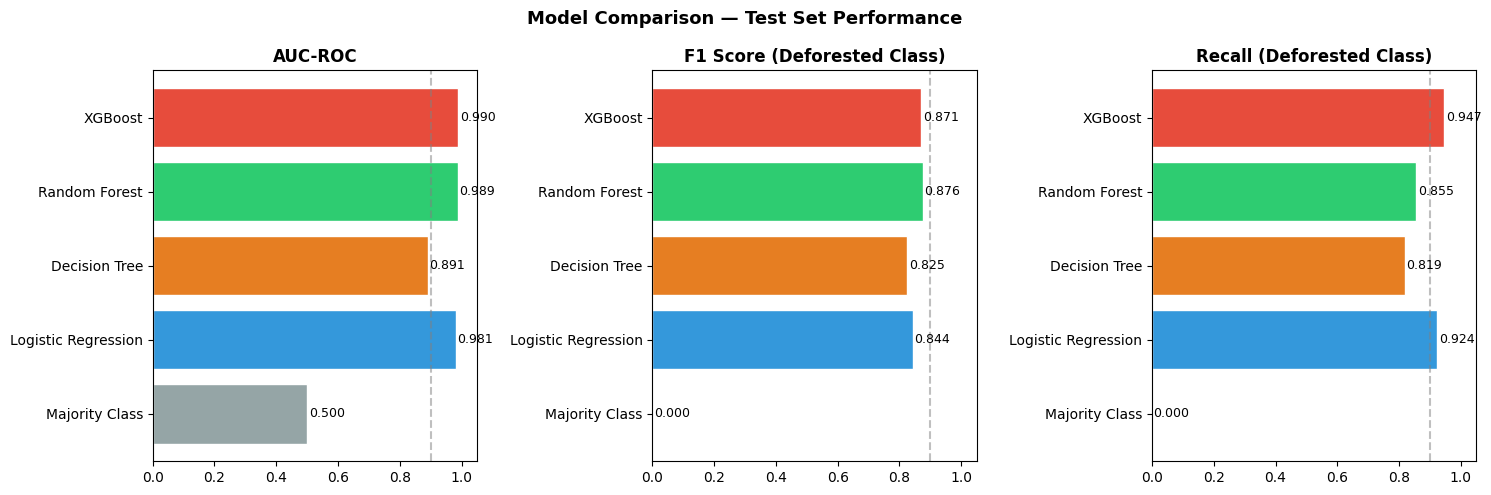

In [28]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models   = comparison_df.index.tolist()
colors   = ['#95a5a6', '#3498db', '#e67e22', '#2ecc71', '#e74c3c']
metrics  = ['AUC-ROC', 'F1 (deforested)', 'Recall']
titles   = ['AUC-ROC', 'F1 Score (Deforested Class)', 'Recall (Deforested Class)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    vals = comparison_df[metric].values
    bars = axes[i].barh(models, vals, color=colors, edgecolor='white')
    axes[i].set_xlim(0, 1.05)
    axes[i].set_title(title, fontweight='bold')
    axes[i].axvline(x=0.9, color='gray', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, vals):
        axes[i].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Model Comparison — Interpretation

| Model | AUC-ROC | F1 | Recall | False Negatives |
|---|---|---|---|---|
| Majority Class | 0.500 | 0.000 | 0.000 | 12,649 |
| Logistic Regression | 0.981 | 0.844 | 0.924 | 963 |
| Decision Tree | 0.891 | 0.825 | 0.819 | 2,285 |
| Random Forest | 0.989 | 0.876 | 0.855 | 1,833 |
| **XGBoost** | **0.990** | **0.871** | **0.947** | **676** |

**Which model wins and why:**  
XGBoost is selected as the final model. It has the highest AUC-ROC (0.990) and by far the lowest false negatives (676), meaning it misses the fewest real deforestation events. In a conservation context, a false negative means a cell being actively cleared receives no enforcement or monitoring response. Minimising this error is the most important objective, making recall the decisive metric alongside AUC.

**Trade-offs between models:**

- **Logistic Regression** has surprisingly high recall (0.924): it casts a wide net and catches most deforested cells, but at the cost of 3,365 false alarms. It is the most interpretable model and a strong choice if explaining predictions to non-technical stakeholders is the priority.

- **Decision Tree** is the weakest real model, lowest AUC (0.891) and high false negatives (2,285). Unlimited depth caused overfitting that hurt generalisation. Not recommended.

- **Random Forest** has the highest precision (0.898) and highest F1 (0.876): it is the most conservative model, flagging cells only when very confident. Fewer false alarms but misses more real deforestation (1,833 FN vs XGBoost's 676).

- **XGBoost** balances high AUC with the best recall. The 2,879 false positives are an acceptable cost, monitoring a cell that turns out to be intact wastes some resources, but missing 676 real clearing events vs 1,833 is a significant conservation gain.

**Final model: XGBoost**, highest AUC, highest recall, lowest false negatives.

---
## Section 5: Error Analysis

Error analysis examines where and why the final model (XGBoost) makes mistakes. We look at three things: which features drive predictions (feature importance), what the misclassified cells look like (false negatives and false positives), and whether errors follow any systematic pattern.

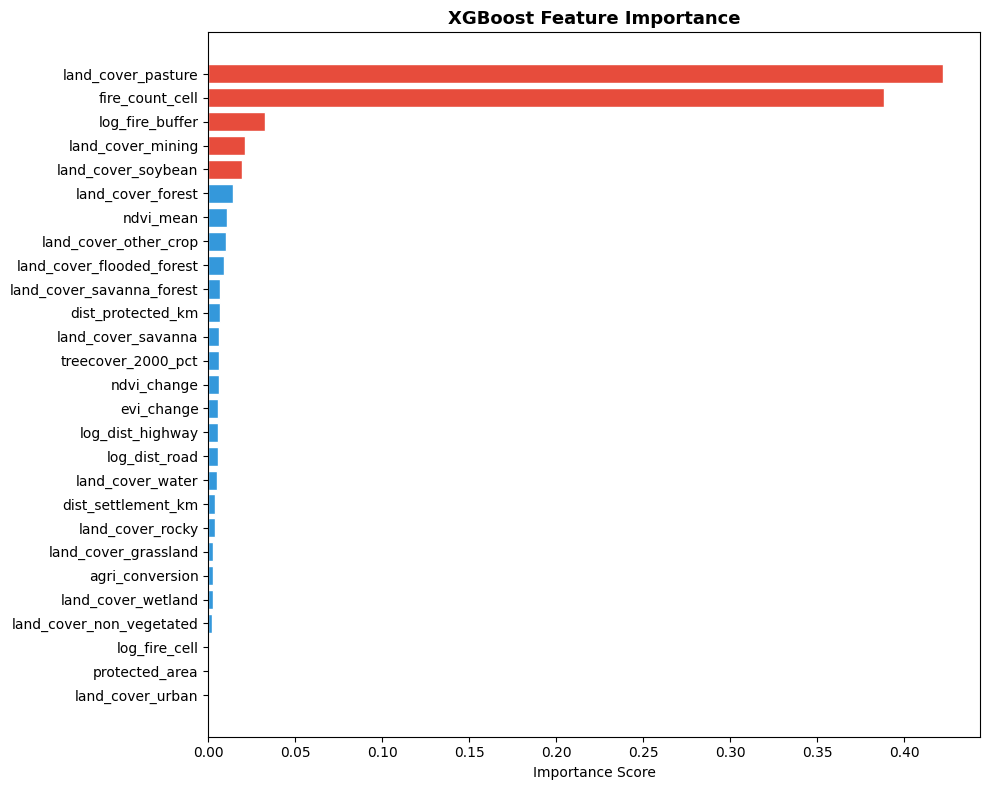

Top 10 most important features:
land_cover_pasture           0.4226
fire_count_cell              0.3883
log_fire_buffer              0.0327
land_cover_mining            0.0213
land_cover_soybean           0.0195
land_cover_forest            0.0144
ndvi_mean                    0.0107
land_cover_other_crop        0.0102
land_cover_flooded_forest    0.0093
land_cover_savanna_forest    0.0069


In [31]:

import matplotlib.pyplot as plt

importance = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if i >= len(importance)-5 else '#3498db' 
          for i in range(len(importance))]
ax.barh(importance.index, importance.values, color=colors, edgecolor='white')
ax.set_title('XGBoost Feature Importance', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(importance.sort_values(ascending=False).head(10).round(4).to_string())

In [32]:


# Add predictions to test set for analysis
X_test_analysis = X_test.copy()
X_test_analysis['true']      = y_test.values
X_test_analysis['predicted'] = y_pred_xgb
X_test_analysis['prob']      = y_prob_xgb

# Isolate error types
false_negatives = X_test_analysis[(X_test_analysis['true']==1) & 
                                   (X_test_analysis['predicted']==0)]
false_positives = X_test_analysis[(X_test_analysis['true']==0) & 
                                   (X_test_analysis['predicted']==1)]
correct_defor   = X_test_analysis[(X_test_analysis['true']==1) & 
                                   (X_test_analysis['predicted']==1)]

print(f"False Negatives (missed deforestation): {len(false_negatives):,}")
print(f"False Positives (false alarms):         {len(false_positives):,}")
print(f"Correctly identified deforested:        {len(correct_defor):,}")

# Compare key features between FN and correctly caught deforested cells
compare_cols = ['log_fire_cell', 'ndvi_change', 'log_dist_road', 
                'log_dist_highway', 'agri_conversion']

print("\n── Feature comparison: Missed vs Caught deforested cells ──")
print(f"{'Feature':<22} {'Missed (FN)':>12} {'Caught':>12} {'Difference':>12}")
for col in compare_cols:
    fn_mean  = false_negatives[col].mean()
    cor_mean = correct_defor[col].mean()
    diff     = fn_mean - cor_mean
    print(f"{col:<22} {fn_mean:>12.3f} {cor_mean:>12.3f} {diff:>+12.3f}")

False Negatives (missed deforestation): 676
False Positives (false alarms):         2,879
Correctly identified deforested:        11,973

── Feature comparison: Missed vs Caught deforested cells ──
Feature                 Missed (FN)       Caught   Difference
log_fire_cell                 0.448        2.055       -1.607
ndvi_change                  -0.010       -0.049       +0.038
log_dist_road                 1.419        0.898       +0.521
log_dist_highway              4.391        3.986       +0.405
agri_conversion               0.001        0.206       -0.204


## Section 5: Error Analysis

Error analysis investigates where and why the final model makes mistakes. Knowing that XGBoost achieves 94.7% recall is useful, but understanding what characterises the 5.3% of deforested cells it still misses is what makes the model actionable in practice. This section examines feature importance to understand what drives predictions, then compares the characteristics of missed cells against correctly caught ones to identify systematic failure patterns.

---

### 5.1 Feature Importance

The two dominant features are `land_cover_pasture` (importance score 0.423) and `fire_count_cell` (importance score 0.388), which together account for over 81% of the model's decision-making weight. Every other feature in the model contributes less than 5% individually.

This result aligns precisely with both the EDA findings and the known ecology of deforestation along BR-163. Pasture is the primary land use conversion pathway in this corridor: forest is cleared, burned, and converted to cattle grazing, meaning a cell already classified as pasture by MapBiomas is almost certainly one that has already undergone deforestation. Fire count is the most direct satellite-observable signal of active slash-and-burn clearing, the dominant clearing method used by smallholders and large landowners alike along the BR-163 frontier.

The remaining features, including log distance to road, NDVI change, distance to settlement, and the other land cover dummies, contribute meaningfully in aggregate but no single one approaches the influence of pasture or fire count. This concentration of importance in two features has direct consequences for where the model fails, as the next section shows.

---

### 5.2 Error Pattern Analysis

**Why does XGBoost miss 676 deforested cells?**

The 676 false negatives are not randomly distributed across the test set. Comparing their feature values against the 11,973 deforested cells the model correctly identified reveals a consistent and interpretable pattern.

`log_fire_cell` averages 0.448 in missed cells compared to 2.055 in correctly caught ones. Since fire count is the second most important feature in the model (38.8% importance weight), cells cleared without burning are nearly invisible to it. Mechanical clearing, selective logging, and chainsaw-based clearing leave no fire signal in the FIRMS satellite data and therefore produce almost no trigger for the model's primary detection mechanism.

`log_dist_road` averages 1.419 in missed cells compared to 0.898 in caught ones. Missed cells are systematically farther from roads. The model has correctly learned that deforestation is strongly concentrated near road access points, but this also means it underestimates risk for remote frontier encroachment where clearing is just beginning to push into roadless areas.

`log_dist_highway` averages 4.391 in missed cells compared to 3.986 in caught ones. Missed cells sit deeper in the forest interior, farther from the BR-163 corridor itself. These are likely the leading edge of the deforestation frontier, where clearing is earliest and least detectable.

`agri_conversion` averages 0.001 in missed cells compared to 0.206 in caught ones. Missed cells have almost no agricultural conversion flag from MapBiomas. This means they have not yet been reclassified as farmland in the land cover dataset, suggesting they are in the very earliest stages of clearing before any agricultural activity has been formally recorded.

`ndvi_change` averages -0.010 in missed cells compared to -0.049 in caught ones. Missed cells show almost no measurable vegetation decline in the NDVI time series. This is consistent with early-stage clearing where canopy removal is partial, or with secondary regrowth after an initial clearing event that temporarily masks the vegetation loss signal.

Taken together, the pattern is clear. XGBoost systematically misses deforestation that is remote, fire-free, early-stage, and not yet recorded as agricultural conversion. These are precisely the hardest cases to detect from satellite data because they have not yet produced the observable signals the model was trained to recognise. This is not a failure of model tuning but a fundamental limitation of the available features.

**Why does XGBoost produce 2,879 false positives?**

False positives are intact cells the model wrongly flags as deforested. Given that the model assigns the highest importance to pasture cover and fire activity, the most likely explanation is that these cells sit near roads, show moderate fire counts from controlled burns or natural savanna fires, and may have some pasture coverage from historical land use, but are not currently undergoing active clearing. The model's aggressive stance toward the minority class, which is what gives it the highest recall of all models, also means it flags ambiguous cells on the side of caution. In a conservation context this is the correct bias: directing monitoring resources toward a cell that turns out to be intact wastes some operational effort, but missing a cell that is actively being cleared allows real deforestation to go unenforced. The 2,879 false positives are an acceptable operational cost given the 676 false negatives they accompany.

## Section 6: Improvements and Next Steps

The current pipeline performs well as a first operational model, but several concrete improvements would meaningfully increase both its accuracy and its real-world reliability. This section outlines the most impactful next steps, organised by category.

---

### 6.1 Additional Feature Engineering

**Spatial lag features** represent the single most impactful improvement available within the current modelling framework. The EDA confirmed that deforestation propagates spatially: a cell's neighbours' land cover state is highly predictive of its own future clearing risk. The active frontier hypothesis, which is well established in the Amazon deforestation literature, states that clearing advances gradually from existing cleared land into adjacent forest. Currently the model treats every grid cell as completely independent with no knowledge of what its neighbours look like. Adding features such as the average deforestation rate in the surrounding 5×5 km block or the number of already-deforested neighbours would directly encode this frontier dynamic. This improvement would most likely reduce false negatives for remote cells that are being gradually encroached upon, which is exactly the failure mode identified in Section 5.

**Temporal fire trajectory** would address the false positive problem identified in the error analysis. Currently `fire_count_cell` collapses the entire 10-year FIRMS fire record into a single cumulative count. This means a cell with stable natural savanna burning over a decade looks identical to a cell with rapidly accelerating fire activity in the last two years, even though these represent completely different ecological situations. Splitting fire count into an early period (2015 to 2019) and a late period (2020 to 2024) would allow the model to distinguish cells where fire is intensifying, which is a strong indicator of active frontier clearing, from those with historically stable burning patterns that are more likely to be natural savanna fires rather than slash-and-burn clearing events.

**Distance to the nearest deforested neighbour** would encode frontier proximity more precisely than highway distance alone. The current distance features measure how far a cell is from road infrastructure, but not how far it is from the advancing edge of already-cleared land. A cell could be far from a highway but immediately adjacent to a recently deforested block, making it extremely high risk in ways the current feature set cannot capture.

---

### 6.2 More Advanced Models

**Spatial Graph Neural Networks** would be the theoretically correct modelling approach for this problem. By treating the grid as a graph where edges connect neighbouring cells, a GNN could model cell-to-cell deforestation propagation explicitly rather than approximating it through engineered spatial lag features. This approach directly accounts for spatial autocorrelation at the architecture level rather than at the feature engineering level.

**Ensemble stacking** would combine the complementary strengths of XGBoost and Random Forest. As shown in Section 4, XGBoost achieves higher recall (0.947 vs 0.855) while Random Forest achieves higher precision and F1. A stacked ensemble that uses both models' predicted probabilities as inputs to a meta-learner could inherit the recall strength of XGBoost and the precision strength of Random Forest simultaneously, potentially outperforming either model individually.

**Threshold optimisation** offers an immediate and low-cost improvement without any retraining. Currently the default classification threshold of 0.5 is used, meaning a cell is predicted as deforested only if the model assigns it a probability above 50%. Lowering this threshold to 0.3 or 0.35 would flag more cells as deforested, increasing recall at the cost of more false positives. Given that minimising false negatives is the primary operational objective, this trade-off is almost always worth making in a conservation deployment context. The optimal threshold can be selected by plotting the precision-recall curve and choosing the point that minimises false negatives subject to an acceptable false positive rate for the monitoring budget available.

---

### 6.3 Better Data

**Socioeconomic drivers** represent the most significant gap in the current feature set. Commodity prices for soy and beef, land tenure records, municipal governance quality indices, and cattle density are all well-documented drivers of Amazon deforestation that are entirely absent from this dataset. Research consistently shows that deforestation rates along BR-163 correlate strongly with international soy prices and the presence or absence of secure land titles. Adding a municipal-level soy price index or cattle density proxy, joined spatially to the grid cells, would likely improve model performance meaningfully and would also improve interpretability for policymakers who need to understand what is driving the predictions.

**Spatial block cross-validation** should replace the current stratified random split in any future iteration of this pipeline. Adjacent grid cells share similar environmental conditions by definition: cells next to each other have similar fire histories, similar road distances, and similar vegetation indices. Random splitting allows the model to train on cells immediately adjacent to test cells, which means it has effectively seen the neighbourhood of every test cell during training. This is a form of spatial leakage that inflates the reported AUC and recall figures. A proper geographic block holdout, where an entire contiguous spatial region is withheld as the test set, would produce a more honest and conservative estimate of how the model generalises to genuinely unseen areas of the corridor.

**Correcting the WDPA protected area join** is a targeted fix that would restore a theoretically important predictor. The near-zero mean of the `protected_area` feature (mean = 0.00002) strongly suggests a coordinate reference system mismatch between the WDPA polygon layer and the BR-163 grid. Protected area status is one of the most important institutional predictors of deforestation: cells inside formally protected reserves face legal barriers to clearing and are monitored more closely by IBAMA. Fixing the spatial join so that cells correctly inherit their protected area membership would restore this signal and would likely improve model performance in the areas of the corridor that overlap with indigenous territories and conservation units.

---

### 6.4 Deployment Considerations

In practice this model would run on a quarterly update cycle, ingesting the latest NASA FIRMS fire detections and MODIS NDVI composites as they become available. The output would be a georeferenced risk raster covering the entire BR-163 corridor, delivered to IBAMA or state-level environmental secretariats as a prioritisation layer. Rather than attempting to monitor all 342,819 grid cells equally, enforcement teams would focus attention on the top 5% of cells by predicted deforestation probability, concentrating limited inspection and satellite tasking resources where the model indicates risk is highest.

---

### 6.5 Monitoring and Model Drift

Deforestation patterns are not static. Commodity price cycles, changes in federal enforcement policy, road expansion, and political transitions all alter where and how fast clearing occurs along BR-163. A model trained on 2015 to 2024 data may become progressively less accurate as the underlying patterns shift. To address this, the model should be retrained annually on updated Hansen GFC forest loss year data as new annual loss maps are released.

Drift detection should monitor the distribution of predicted deforestation probabilities over time. If the proportion of cells flagged as high risk changes sharply between quarterly runs without a corresponding change in the input data, this signals that something in the underlying pattern has shifted and the model is no longer reliably calibrated. A simple monitoring dashboard tracking the mean predicted probability and the proportion of cells above the classification threshold across each quarterly update would provide an early warning system for when retraining is needed.

## Section 7: Conclusion

This project built and evaluated a binary classification pipeline to predict deforestation risk across 342,819 grid cells along Brazil's BR-163 highway corridor, using features derived from satellite fire detection, road proximity, vegetation indices, and land cover history spanning 2015 to 2024.

---

### Final Model Selection

XGBoost (learning_rate=0.1, max_depth=6, n_estimators=500) was selected as the final model based on three results that matter most for this conservation problem.

First, it achieved the highest AUC-ROC of 0.990 across all models evaluated, meaning it correctly ranks a randomly chosen deforested cell above a randomly chosen intact cell 99.0% of the time across every possible classification threshold simultaneously.

Second, it achieved the highest recall of 0.947, correctly identifying 11,973 out of 12,649 genuinely deforested cells in the held-out test set. Recall is the decisive metric here because every missed deforested cell is a real clearing event that receives no monitoring or enforcement response in an operational setting.

Third, it produced the lowest false negative count of all models at 676, compared to 963 for Logistic Regression, 1,833 for Random Forest, and 2,285 for the Decision Tree. Reducing false negatives from 1,833 to 676 means 1,157 additional deforestation events are caught and flagged for action. In a conservation context where missed deforestation allows clearing to continue undetected and unenforced, this difference is operationally significant.

Random Forest achieved a higher F1 score (0.876 vs 0.871) and fewer false positives (1,231 vs 2,879), but its false negative count of 1,833 makes it a less suitable choice for this specific problem. Minimising missed deforestation takes priority over minimising false alarms, and XGBoost delivers on that priority more effectively than any alternative evaluated.

---

### Is Performance Sufficient for Operational Use?

The model is strong enough to serve as a prioritisation tool, directing monitoring and enforcement resources toward the highest-risk cells in the corridor rather than surveying all 342,819 cells uniformly. An AUC of 0.990 and recall of 0.947 represent genuine and reliable discrimination that would add meaningful value to conservation operations.

However, the model is not reliable enough for fully automated enforcement decisions without human validation. The 676 remaining false negatives represent real clearing events the model lets through, and the 2,879 false positives represent intact cells that would waste inspection resources if acted upon automatically. Human review of flagged cells before any enforcement action is taken remains essential.

It is also important to note that the reported performance figures are optimistic. The current stratified random train-test split does not account for spatial autocorrelation between adjacent grid cells. A proper geographic block holdout would likely produce lower but more honest AUC and recall estimates, reflecting how the model truly generalises to unseen areas of the corridor rather than to cells immediately adjacent to its training data.

---

### Key Limitations

The model relies heavily on two features, `land_cover_pasture` (42.3% importance) and `fire_count_cell` (38.8% importance), which together account for over 81% of its decision-making. This concentration means the model is effectively blind to deforestation that does not involve fire or pasture conversion. The error analysis confirmed this directly: missed cells had a mean log fire count of 0.448 compared to 2.055 for correctly caught cells, and a mean agricultural conversion rate of 0.001 compared to 0.206. Mechanical clearing, selective logging, and early-stage frontier encroachment that has not yet produced a fire or agricultural conversion signal in the satellite record are the cases the model consistently fails to detect.

The `protected_area` feature is effectively non-functional due to a suspected coordinate reference system mismatch in the WDPA spatial join, removing a theoretically important institutional predictor entirely. Socioeconomic drivers including commodity prices, land tenure records, and cattle density are absent from the dataset despite being well-documented deforestation drivers in the BR-163 literature.

---

### Most Important Next Step

The single most impactful next step is to add spatial lag features encoding neighbourhood deforestation rates and to implement spatial block cross-validation. These two changes address the model's primary failure mode and its most significant evaluation bias simultaneously. Spatial lag features would give the model awareness of the active deforestation frontier, directly reducing false negatives for the remote, early-stage clearing events it currently misses. Spatial block cross-validation would replace the current optimistic performance estimate with one that honestly reflects generalisation to unseen geographic areas, which is the metric that actually matters for operational deployment along BR-163.